<a href="https://colab.research.google.com/github/sascott9655/ADS-504-Machine-Learning/blob/main/Sample_Code_HW_Assignment_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# These IMPORTs will be needed :)

import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
%matplotlib inline

**Load and understand  Data**

Animal shelter data set



In [3]:
data = pd.read_csv('/content/sample_data/shelter_data.csv')  #Read the data here
data.describe()

,AnimalID,Name,DateTime,OutcomeType,OutcomeSubtype,AnimalType,SexuponOutcome,AgeuponOutcome,Breed,Color
count,26729,19038,26729,26729,13117,26729,26728,26711,26729,26729
unique,26729,6374,22918,5,16,2,5,44,1380,366
top,A706629,Max,2015-08-11 00:00:00,Adoption,Partner,Dog,Neutered Male,1 year,Domestic Shorthair Mix,Black/White
freq,1,136,19,10769,7816,15595,9779,3969,8810,2824


In [4]:
data.head()

,AnimalID,Name,DateTime,OutcomeType,OutcomeSubtype,AnimalType,SexuponOutcome,AgeuponOutcome,Breed,Color
0,A671945,Hambone,2014-02-12 18:22:00,Return_to_owner,NaN,Dog,Neutered Male,1 year,Shetland Sheepdog Mix,Brown/White
1,A656520,Emily,2013-10-13 12:44:00,Euthanasia,Suffering,Cat,Spayed Female,1 year,Domestic Shorthair Mix,Cream Tabby
2,A686464,Pearce,2015-01-31 12:28:00,Adoption,Foster,Dog,Neutered Male,2 years,Pit Bull Mix,Blue/White
3,A683430,NaN,2014-07-11 19:09:00,Transfer,Partner,Cat,Intact Male,3 weeks,Domestic Shorthair Mix,Blue Cream
4,A667013,NaN,2013-11-15 12:52:00,Transfer,Partner,Dog,Neutered Male,2 years,Lhasa Apso/Miniature Poodle,Tan


#Section 1
###*Preprocessing the Data*

In [5]:
# this line drops any rows with missing data
cleaned_data = data.dropna()
# here we grab the data we want from pandas
X_data = cleaned_data[['AnimalType','SexuponOutcome','AgeuponOutcome']]
y_data = cleaned_data[['OutcomeType']]
#print(X_data['AgeuponOutcome'].value_counts())
enc = OrdinalEncoder()
enc.fit(X_data)
le = preprocessing.LabelEncoder()
le.fit(y_data)
data_categorical = pd.DataFrame(enc.transform(X_data),
columns=list(X_data))
X=data_categorical
y=le.transform(y_data)
# Without changing the random state, divide your data into 50% for test and 50% for train
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


#Section 2

###*Model evaluation*

Base Decision Tree Classifer

In [6]:
#Apply the model here
clf = tree.DecisionTreeClassifier()  #Create your model here
short_tree = clf.fit(X_train, y_train)   #Fit on training data
y_pred = clf.predict(X_test)
print('accuracy %2.2f ' % accuracy_score(y_test,y_pred))

accuracy 0.73 


In [7]:
# Let's see the confusion matrix together
cm_clf = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred))
labels=['Adoption', 'Died', 'Euthanasia', 'Transfer']
test_results = pd.DataFrame(cm_clf,index=labels,columns=labels)
display(test_results)

,Adoption,Died,Euthanasia,Transfer
Adoption,229,0,9,204
Died,1,0,1,13
Euthanasia,2,0,22,160
Transfer,59,0,26,1019


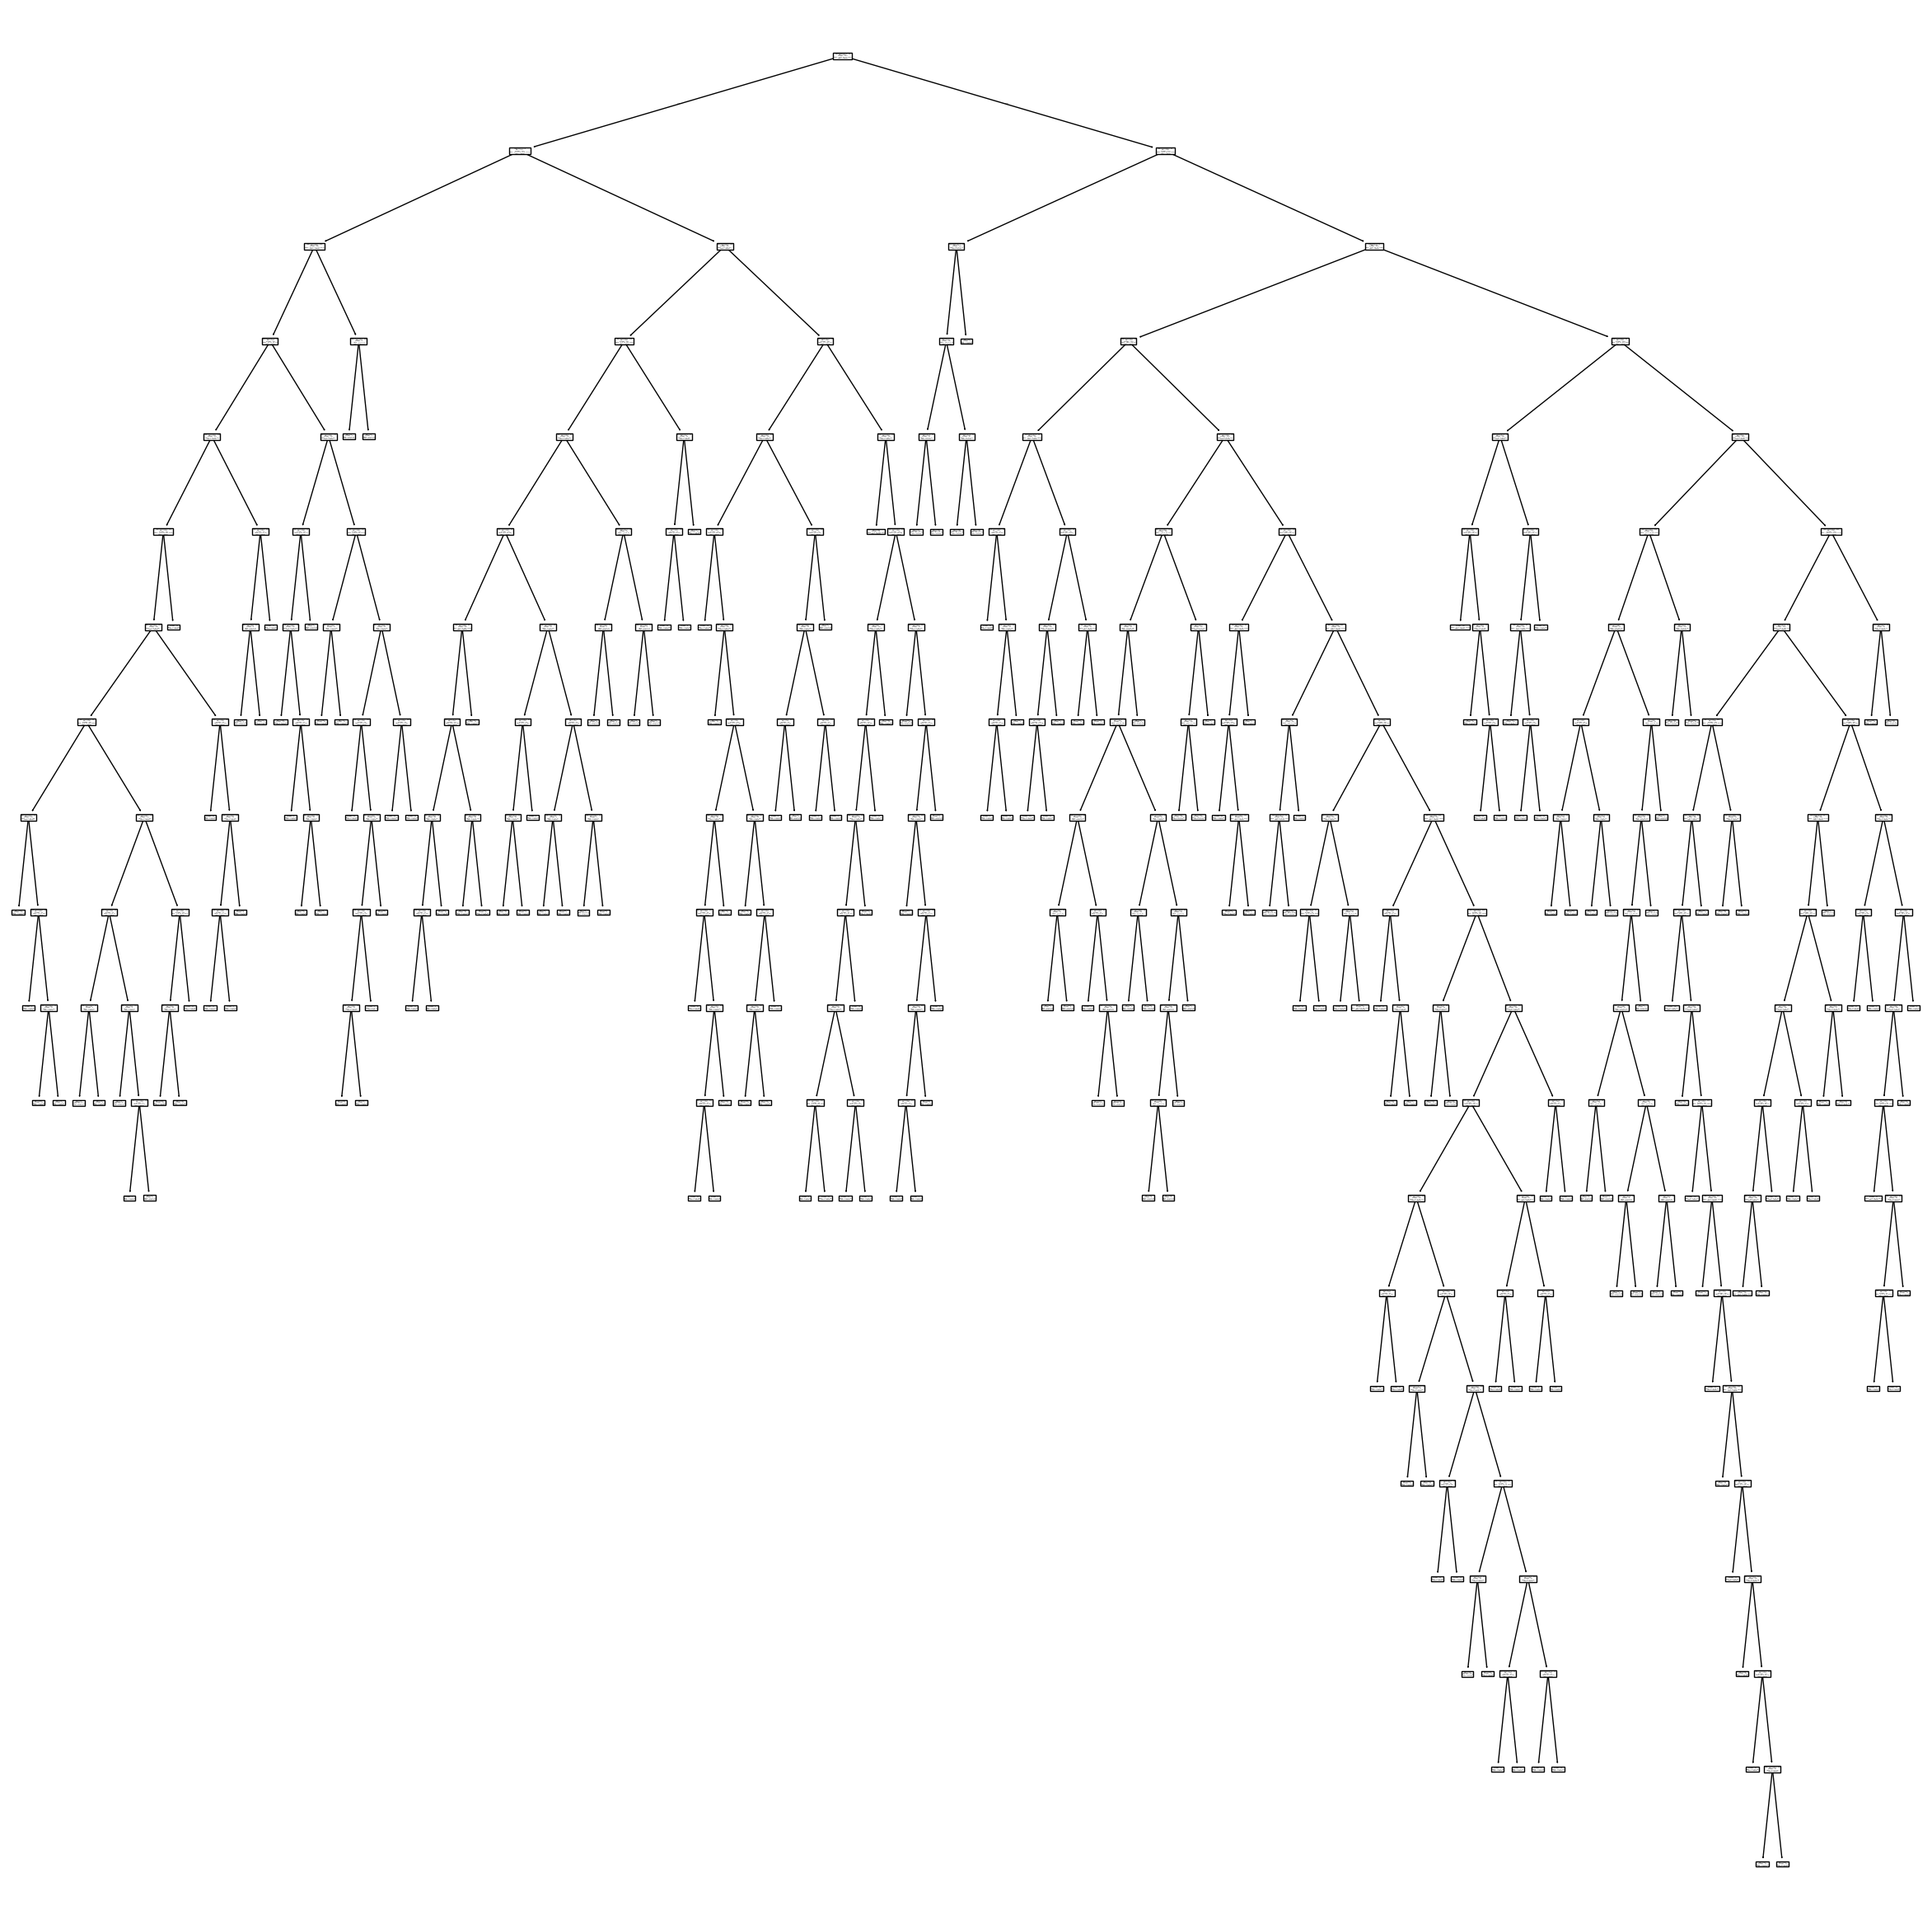

In [8]:
# Plot the decision tree
fig,ax = plt.subplots(figsize = (30,30))
treeplot = tree.plot_tree(clf, feature_names=['AnimalType','SexuponOutcome','AgeuponOutcome'],
class_names = ['Adoption', 'Died', 'Euthanasia', 'Transfer'],ax=ax)
fig.savefig("unpruned_tree.pdf", format="pdf")


**Problem 2.1. Animal Control**

Decision Tree with max_depth = 3

In [9]:
# Train a new decision tree here! Remember this time maxdepth should be 3 (short tree)
#Apply the model here
short_tree = tree.DecisionTreeClassifier(max_depth=3)  #Create your model here
short_tree = short_tree.fit(X_train, y_train)   #Fit on training data
y_pred_short = short_tree.predict(X_test)
print('accuracy %2.2f ' % accuracy_score(y_test,y_pred_short))

accuracy 0.65 


In [10]:
# Create confusion matrix
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred))
labels=['Adoption', 'Died', 'Euthanasia', 'Transfer']
test_results = pd.DataFrame(cm,index=labels,columns=labels)
display(test_results)

,Adoption,Died,Euthanasia,Transfer
Adoption,229,0,9,204
Died,1,0,1,13
Euthanasia,2,0,22,160
Transfer,59,0,26,1019


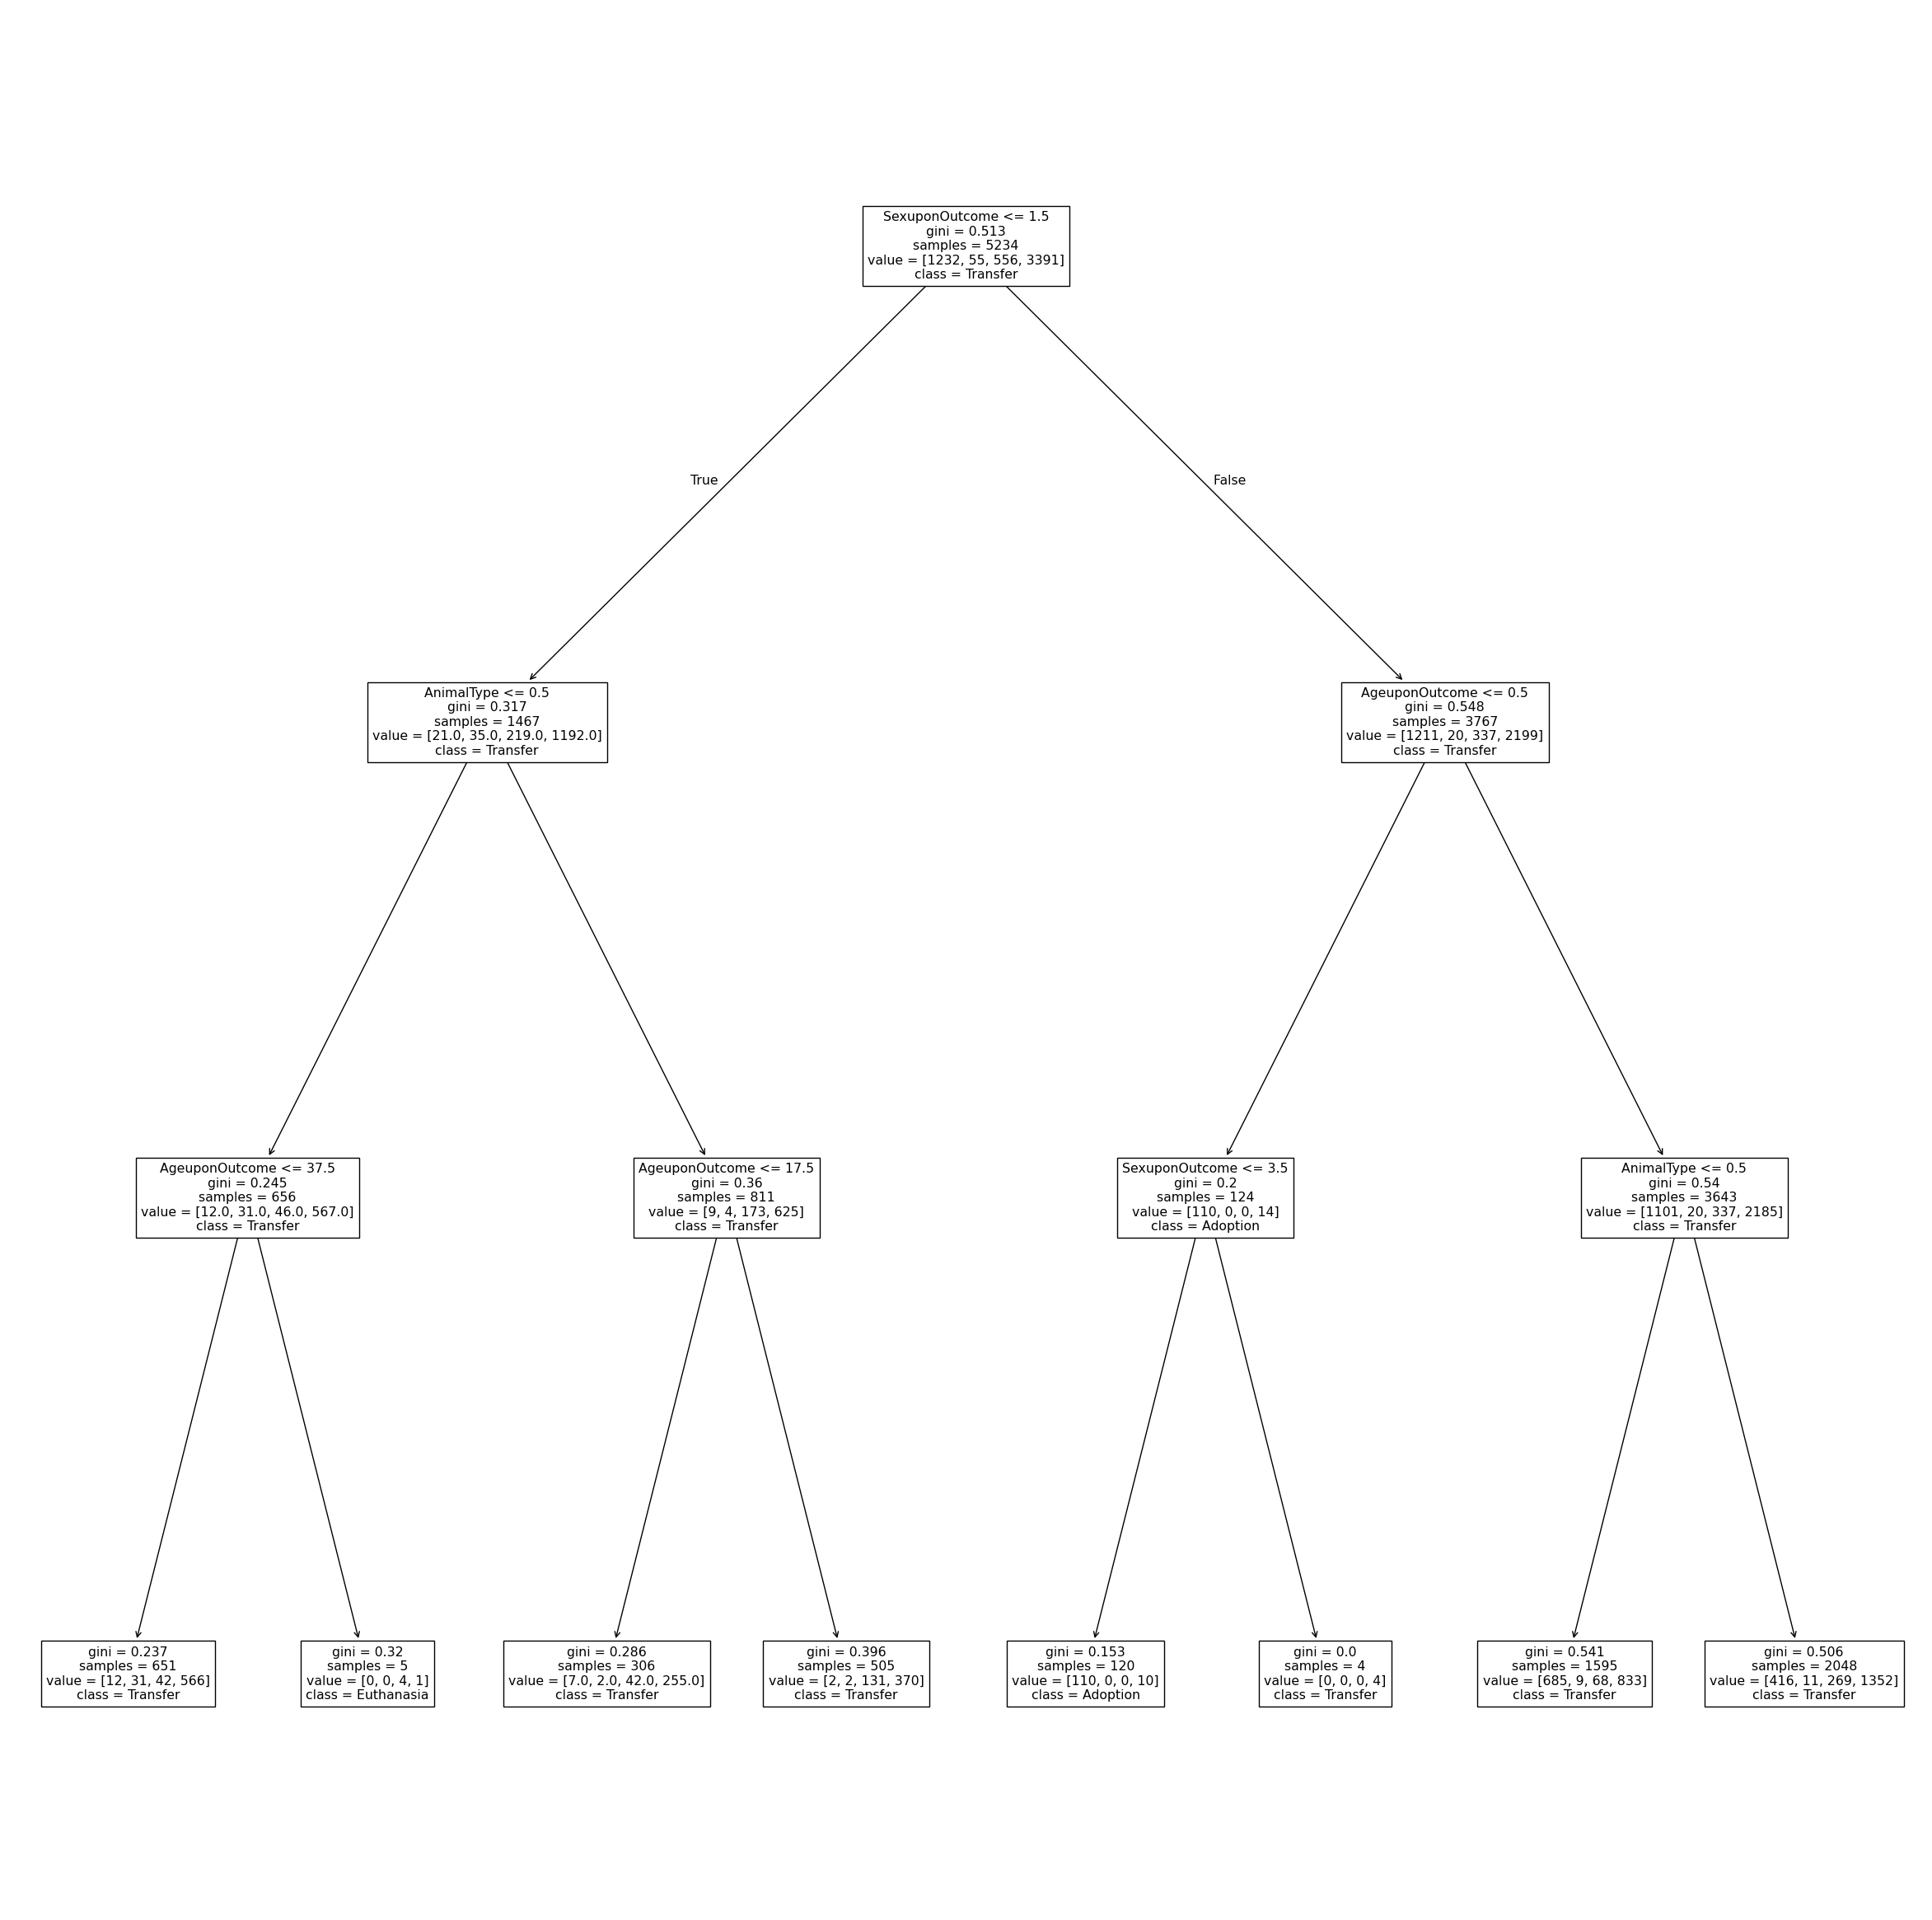

In [11]:
# Plot the tree here
fig,ax = plt.subplots(figsize = (30,30))
treeplot = tree.plot_tree(short_tree, feature_names=['AnimalType','SexuponOutcome','AgeuponOutcome'],
class_names = ['Adoption', 'Died', 'Euthanasia', 'Transfer'],ax=ax)
fig.savefig("short_tree.pdf", format="pdf")

#Section 3

###*Hyperparameter Tuning*

**Varying Tree Depth using Loop**

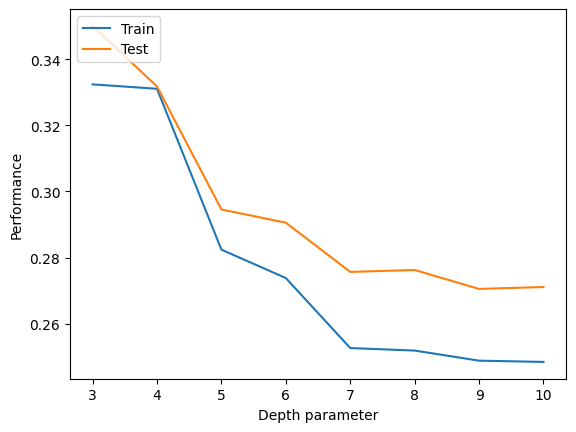

In [12]:
train_errors = list()
test_errors = list()
for x in range(3,11):
  #Create multiple models here each based on the x variable above
  # Store the result of modes in train_erors and test_errors variables
  clf = tree.DecisionTreeClassifier(max_depth=x, random_state=42)   #Fit on training data
  clf.fit(X_train, y_train)
  train_pred = clf.predict(X_train)
  test_pred = clf.predict(X_test)
  train_errors.append(1-accuracy_score(y_train, train_pred))
  test_errors.append(1-accuracy_score(y_test, test_pred))
# Plot of test and training erros
plt.plot(range(3,11),train_errors, label='Train')
plt.plot(range(3,11),test_errors, label='Test')
plt.legend(loc='upper left')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("tree_depth_plot.pdf", format="pdf")

Initially the test error at max_depth = 3, is higher than the training error. Both errors decrease as the number of max_depth of tree nodes increases. The training error drop off is more noticeable as the error changes significantly especially from max_depth = 4 to 5 (the drop off is also noticeable on the test error from 4 to 5), while the testing error overall error decreases at a more steady rate.

**Tree Pruning using the ccp_alpha parameter**

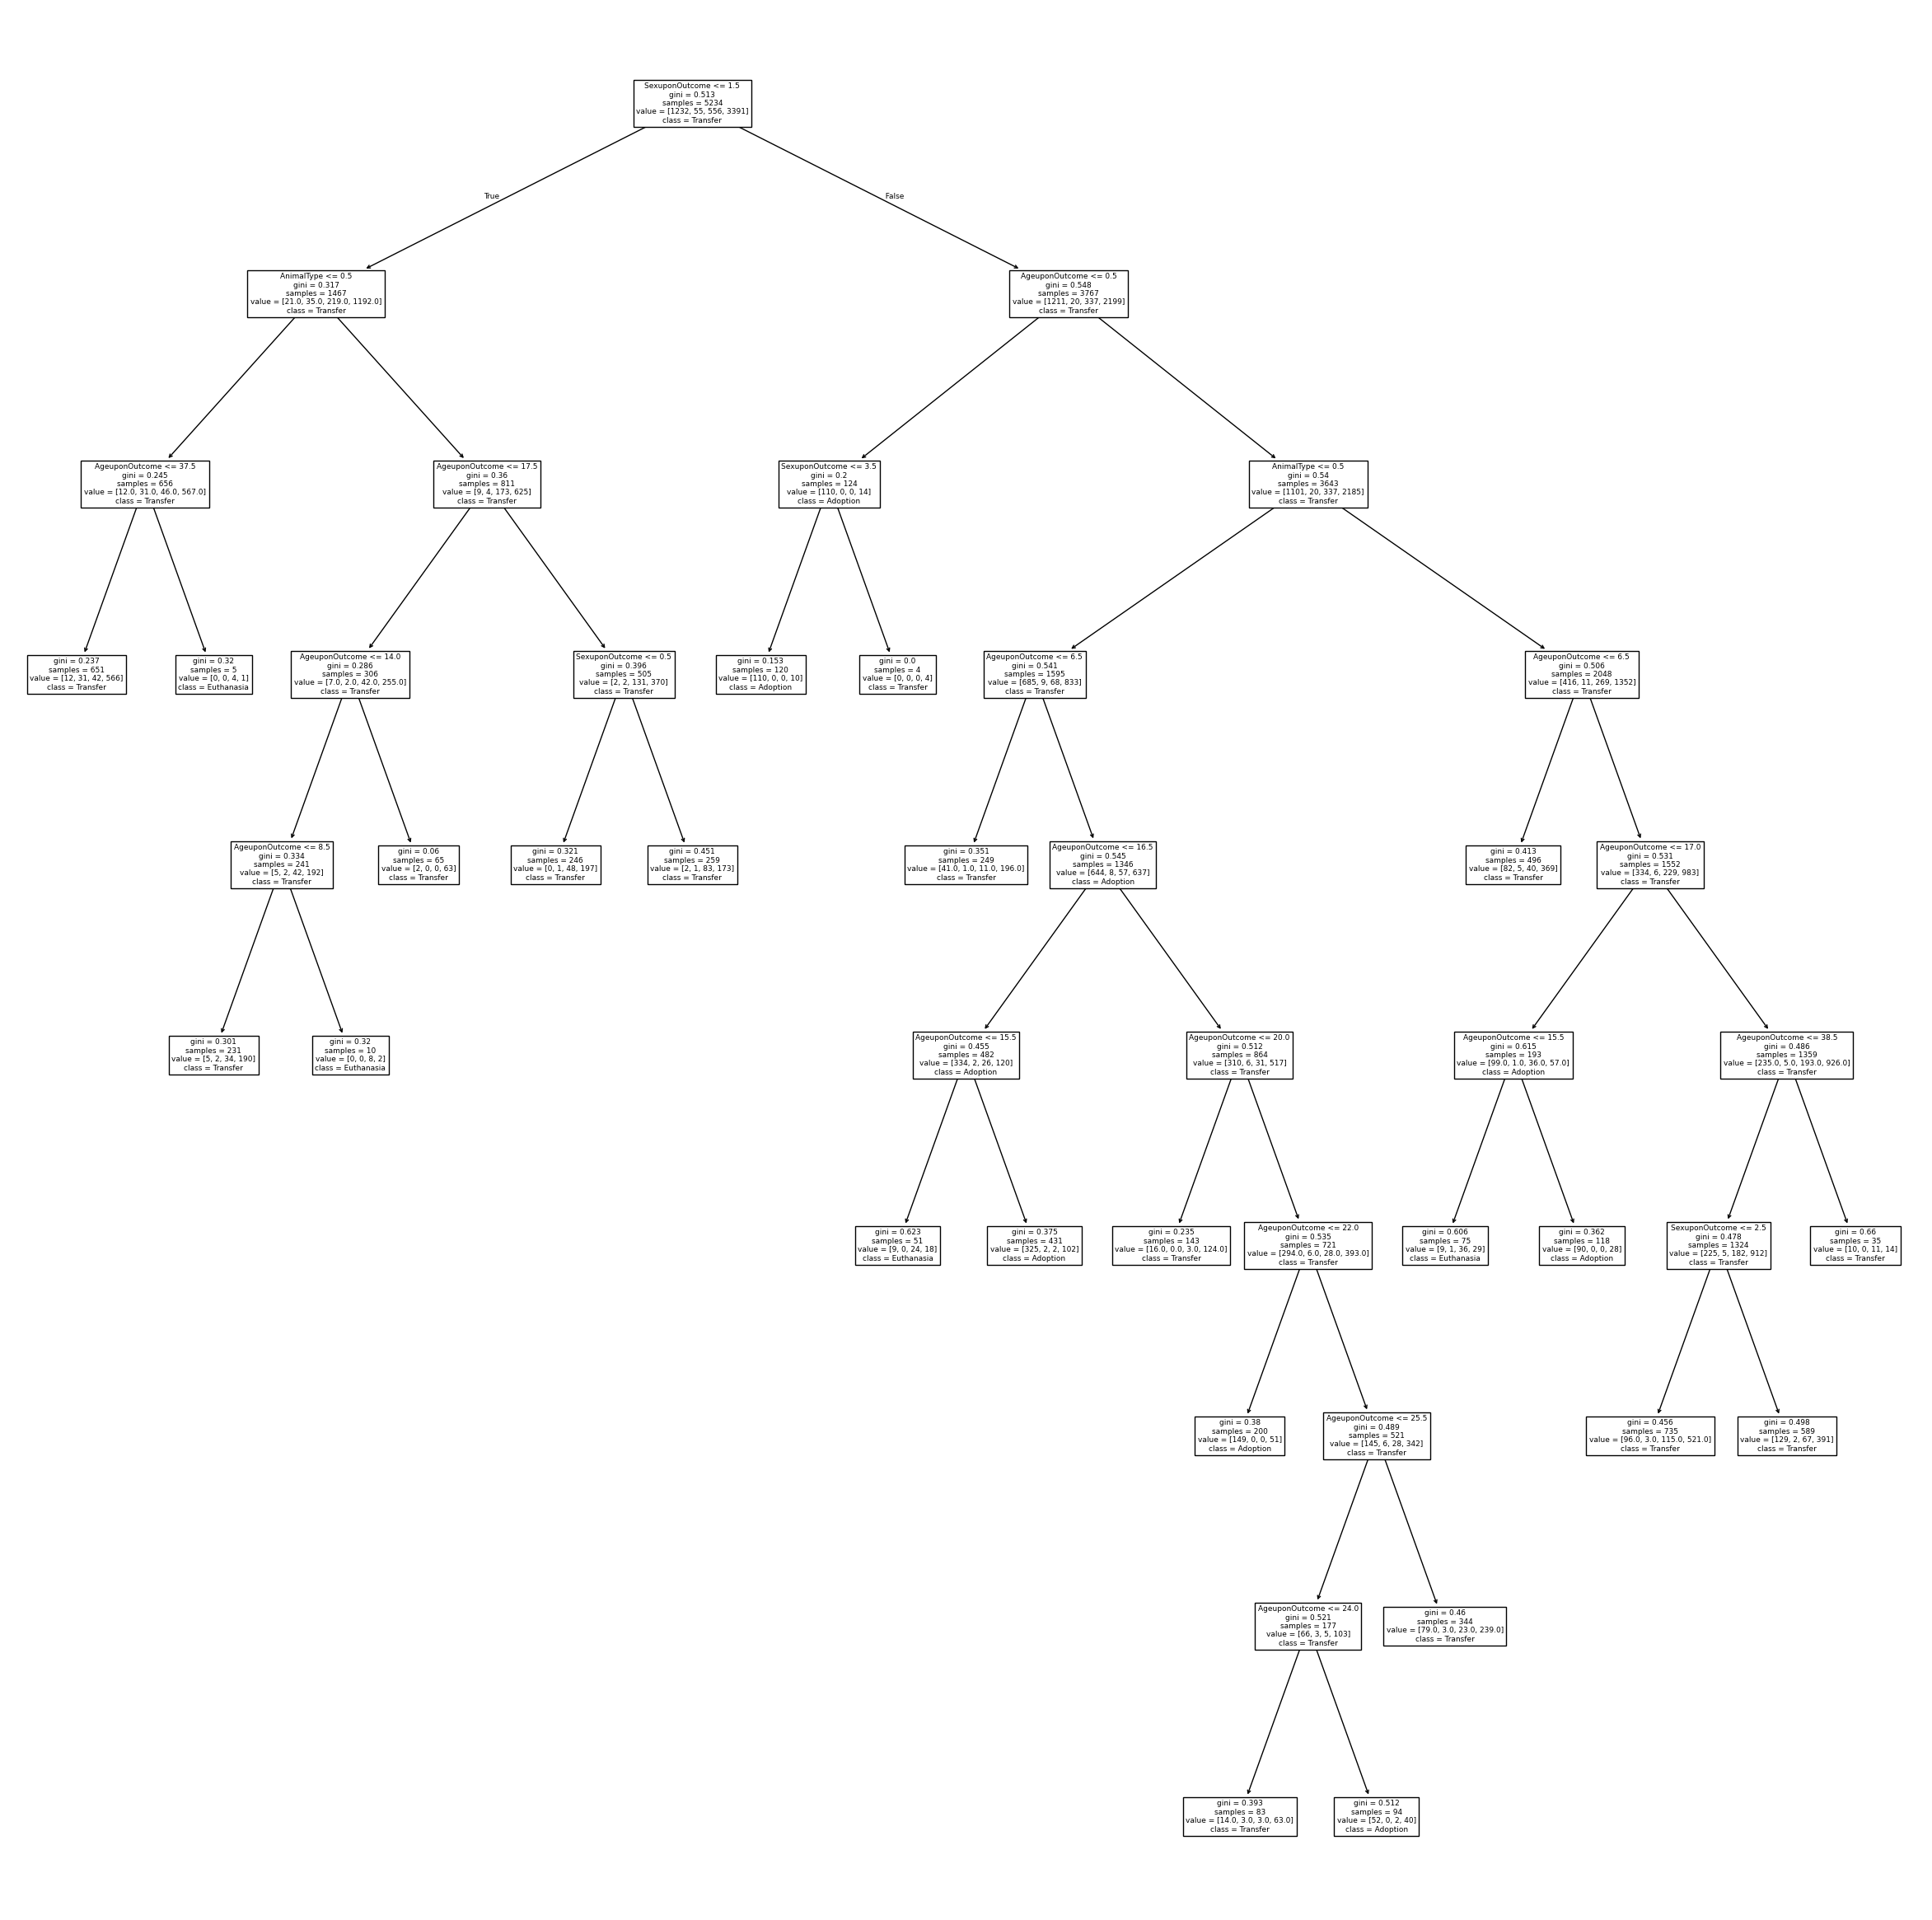

In [13]:
#clf is unpruned tree
fig,ax = plt.subplots(figsize = (30,30))
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
clfs = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
train_scores = []
test_scores = []

for clf in clfs:
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))
best_alpha = ccp_alphas[test_scores.index(max(test_scores))]
tree_prune = tree.DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_prune.fit(X_train,y_train)
treeplot = tree.plot_tree(tree_prune, feature_names=['AnimalType','SexuponOutcome','AgeuponOutcome'],
class_names = ['Adoption', 'Died', 'Euthanasia', 'Transfer'],ax=ax)
fig.savefig("pruned_tree.pdf", format="pdf")

**Comparing Accuracy of Pruned Tree vs Unpruned   (Base) Tree Model**

In [14]:
y_pred4 = tree_prune.predict(X_test)
print('accuracy %2.2f ' % accuracy_score(y_test,y_pred4))

accuracy 0.73 


The tree pruned accuracy is slightly better than the unpruned tree. This means that the unpruned
tree overall does a good job optimizing the best hyperparameter automatically. The pruned tree however can make incremental improvements which can make all the difference, especially when working for a large corporation.


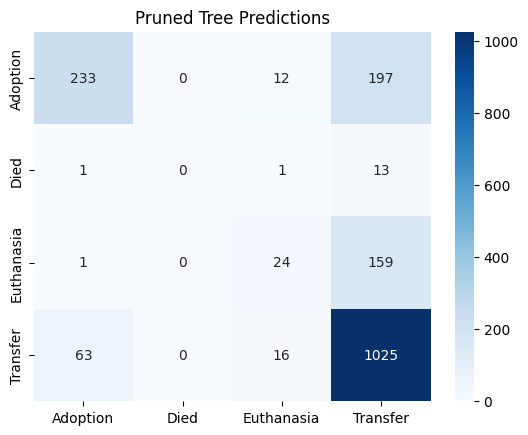

In [15]:
# Create two confusion matrices here. The first confusion matrix shows predictions for the pruned tree and the second one
# predictions for the unpruned one
cm_pruned = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred4))
sns.heatmap(cm_pruned, xticklabels =['Adoption', 'Died', 'Euthanasia', 'Transfer'],
            yticklabels=['Adoption', 'Died', 'Euthanasia', 'Transfer'],
            annot=True, fmt='d', cmap = 'Blues')
plt.title('Pruned Tree Predictions')
plt.show()
fig.savefig("pruned_tree_cm.pdf", format="pdf")


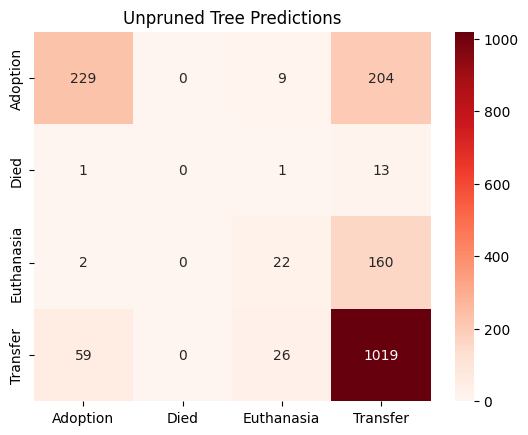

In [16]:
cm_unpruned = confusion_matrix(le.inverse_transform(y_test),le.inverse_transform(y_pred))
sns.heatmap(cm_unpruned, xticklabels =['Adoption', 'Died', 'Euthanasia', 'Transfer'],
            yticklabels=['Adoption', 'Died', 'Euthanasia', 'Transfer'],
            annot=True, fmt='d', cmap = 'Reds')
plt.title('Unpruned Tree Predictions')
plt.show()
fig.savefig("unpruned_tree_cm.pdf", format="pdf")

#Text Data

In [17]:
text_data = pd.read_csv('/content/sample_data/text_data.csv') # Read data remember (meta_author will be the target)

In [18]:
text_data.head()

,Unnamed: 0,meta_author,meta_title,000,10,11,13,136,13th,1648,...,yielding,yoke,yokes,york,young,yourselves,zaleucus,zeal,zealand,zealous
0,0,hamilton,general introduction for the independent journ...,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,3,0,0
1,1,jay,concerning dangers from foreign force and infl...,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,jay,the same subject continued concerning dangers ...,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,3,jay,the same subject continued concerning dangers ...,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,4,jay,the same subject continued concerning dangers ...,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,0,0


#Section 1
Preprocessing

In [19]:
# this line drops any rows with missing data
cleaned_data = data.dropna()
# here we grab the data we want from pandas
X_data = cleaned_data[['AnimalType','SexuponOutcome','AgeuponOutcome']]
y_data = cleaned_data[['OutcomeType']]
#print(X_data['AgeuponOutcome'].value_counts())
enc = OrdinalEncoder()
enc.fit(X_data)
le = preprocessing.LabelEncoder()
le.fit(y_data)
data_categorical = pd.DataFrame(enc.transform(X_data),
columns=list(X_data))
X=data_categorical
y=le.transform(y_data)
# Without changing the random state, divide your data into 50% for test and 50% for train
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [20]:
# Create the decision tree here Randomstate=42 90% training and 10% testing
text_data = text_data.dropna()
X = text_data.drop(columns=['Unnamed: 0', 'meta_author', 'meta_title'])
#print(X)
le = preprocessing.LabelEncoder()
labels = text_data['meta_author']
le.fit(labels)
y=le.transform(labels)


#Section 2
##Model Performance on Text Data

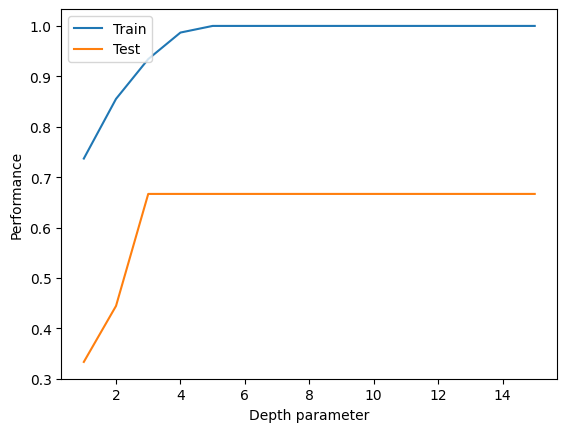

In [21]:

#Create a loop of max depth from 1 to 16 similar to previous step and draw the
#above mentioned graph
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.90, test_size=0.10,
                                                    random_state=42)

train_acc = list()
test_acc = list()

for x in range(1,16):
  t = tree.DecisionTreeClassifier(random_state=42, max_depth=x)
  t.fit(X_train, y_train)
  train_pred = t.predict(X_train)
  test_pred = t.predict(X_test)
  train_acc.append(accuracy_score(y_train, train_pred))
  test_acc.append(accuracy_score(y_test, test_pred))
plt.plot(range(1,16),train_acc, label='Train')
plt.plot(range(1,16),test_acc, label='Test')
plt.legend(loc='upper left')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("tree_depth_plot_text.pdf", format="pdf")


#Section 3

##Tuning Text Data Size to see affects on Hyperparameter(s)

###**small_vocab_X**

In [22]:
# With a simple code, you can see the frequency of the words
text_frequecies = X.sum()
text_frequecies.sort_values()
display(text_frequecies)
kept_words = text_frequecies[text_frequecies<2]
# this line (above) first creates a binary vector for each word, telling us if it appears twice or more
# in the dataset. it then uses that vector to index into text_frequencies to subset only the data
# for which this binary vector evaluates to TRUE. This simple indexing can really help to chop through
# a huge pandas dataframe.
print(kept_words)
small_vocab_X= X [kept_words.index] #this just has a list of vectors of words that show up only once
print(type(small_vocab_X))
# notice how kept_words.index is a list of strings, the same you can use to access the headers of X..

,0
000,2
10,2
11,2
13,1
136,1
...,...
yourselves,1
zaleucus,1
zeal,26
zealand,1


13            1
136           1
13th          1
1648          1
1683          1
             ..
yes           1
yokes         1
yourselves    1
zaleucus      1
zealand       1
Length: 2975, dtype: int64
<class 'pandas.core.frame.DataFrame'>


**Apply small_vocab_X for model evaluation**

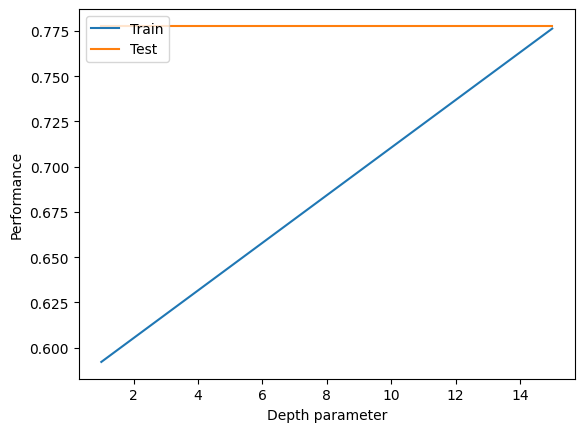

In [23]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16) with smaller word dataset small_vocab_X
# Plot the above graph again
X_train1, X_test1, y_train1, y_test1 = train_test_split(small_vocab_X, y, train_size=0.90, test_size=0.10,
                                                    random_state=42)


train_acc1 = list()
test_acc1 = list()

for x in range(1,16):
  t1 = tree.DecisionTreeClassifier(random_state=42, max_depth=x)
  t1.fit(X_train1, y_train1)
  train_pred1 = t1.predict(X_train1)
  test_pred1 = t1.predict(X_test1)
  train_acc1.append(accuracy_score(y_train1, train_pred1))
  test_acc1.append(accuracy_score(y_test1, test_pred1))
plt.plot(range(1,16),train_acc1, label='Train')
plt.plot(range(1,16),test_acc1, label='Test')
plt.legend(loc='upper left')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("small_vocab_X.pdf", format="pdf")



###**large_vocab_X**




In [24]:
# Same as before create the most frequent words
kept_words2 = text_frequecies[text_frequecies>100]
# this line (above) first creates a binary vector for each word, telling us if it appears twice or more
# in the dataset. it then uses that vector to index into text_frequencies to subset only the data
# for which this binary vector evaluates to TRUE. This simple indexing can really help to chop through
# a huge pandas dataframe.
print(kept_words2)
large_vocab_X= X [kept_words2.index]

against    331
all        731
america    115
among      129
another    155
          ... 
whole      139
within     118
without    207
yet        121
york       150
Length: 150, dtype: int64


**Evaluate model on large_vocab_X**

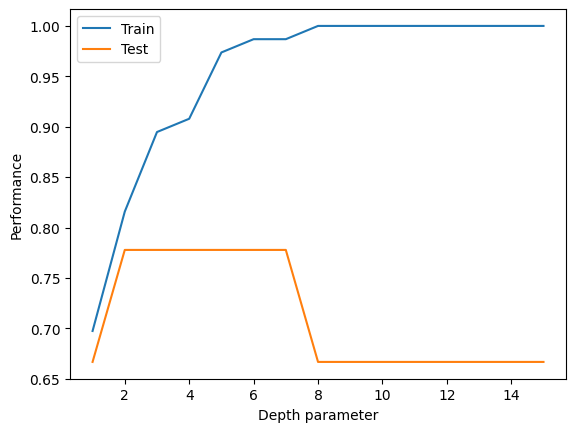

In [25]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16) with smaller word dataset large_vocab_X
# Plot the above graph again

X_train2, X_test2, y_train2, y_test2 = train_test_split(large_vocab_X, y, train_size=0.90, test_size=0.10,
                                                    random_state=42)

train_acc2 = list()
test_acc2 = list()

for x in range(1,16):
  t2 = tree.DecisionTreeClassifier(random_state=42, max_depth=x)
  t2.fit(X_train2, y_train2)
  train_pred2 = t2.predict(X_train2)
  test_pred2 = t2.predict(X_test2)
  train_acc2.append(accuracy_score(y_train2, train_pred2))
  test_acc2.append(accuracy_score(y_test2, test_pred2))
plt.plot(range(1,16),train_acc2, label='Train')
plt.plot(range(1,16),test_acc2, label='Test')
plt.legend(loc='upper left')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("large_vocab_X.pdf", format="pdf")

The model shown for training data on large_vocab_X which has words that appear one hundred times or more is overfitting. This is displayed by the training curve in blue steadily increasing to reach 100% accuracy as the test curve rises then falls and then flatlines at around 66% accuracy. This is happening because there are very few words that appear in the document over 100 times, so the model is able to memorize these words and not generalize to new words.

#**Audio Data**

In [26]:
audio_data = pd.read_csv('/content/sample_data/audio_data.csv') # This time you should drop two columns first: filename and label

In [27]:
audio_data.head()

audio_data = audio_data.drop(columns=['filename', 'label', 'Unnamed: 0'])

In [28]:
# Desing Decision tree here 80% training 20% testing
X = audio_data.iloc[:,1:] # dont have target var in predictors
y = audio_data['label_text']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

#Section 1
##**Baseline Model evaluation on Audio data**

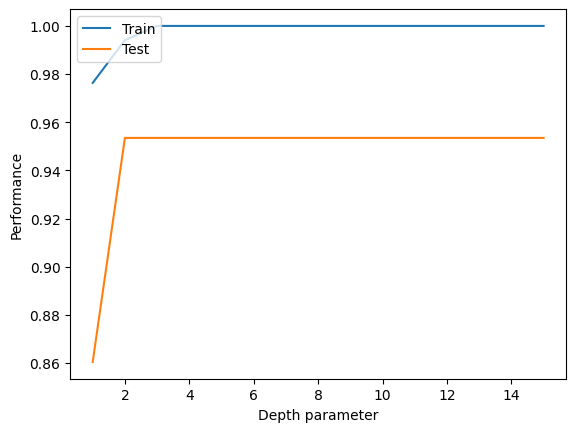

In [29]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16)
# Plot the above graph again
audio_train_acc = list()
audio_test_acc = list()
audio_trees = list()

for x in range(1,16):
  audio_tree = tree.DecisionTreeClassifier(random_state=42, max_depth=x)
  audio_tree.fit(X_train, y_train)
  audio_trees.append(audio_tree)
  audio_train_pred = audio_tree.predict(X_train)
  audio_test_pred = audio_tree.predict(X_test)
  audio_train_acc.append(accuracy_score(y_train, audio_train_pred))
  audio_test_acc.append(accuracy_score(y_test, audio_test_pred))
plt.plot(range(1,16),audio_train_acc, label='Train')
plt.plot(range(1,16),audio_test_acc, label='Test')
plt.legend(loc='upper left')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("base_audio.pdf", format="pdf")

**Plotting Tree when max_depth=5**

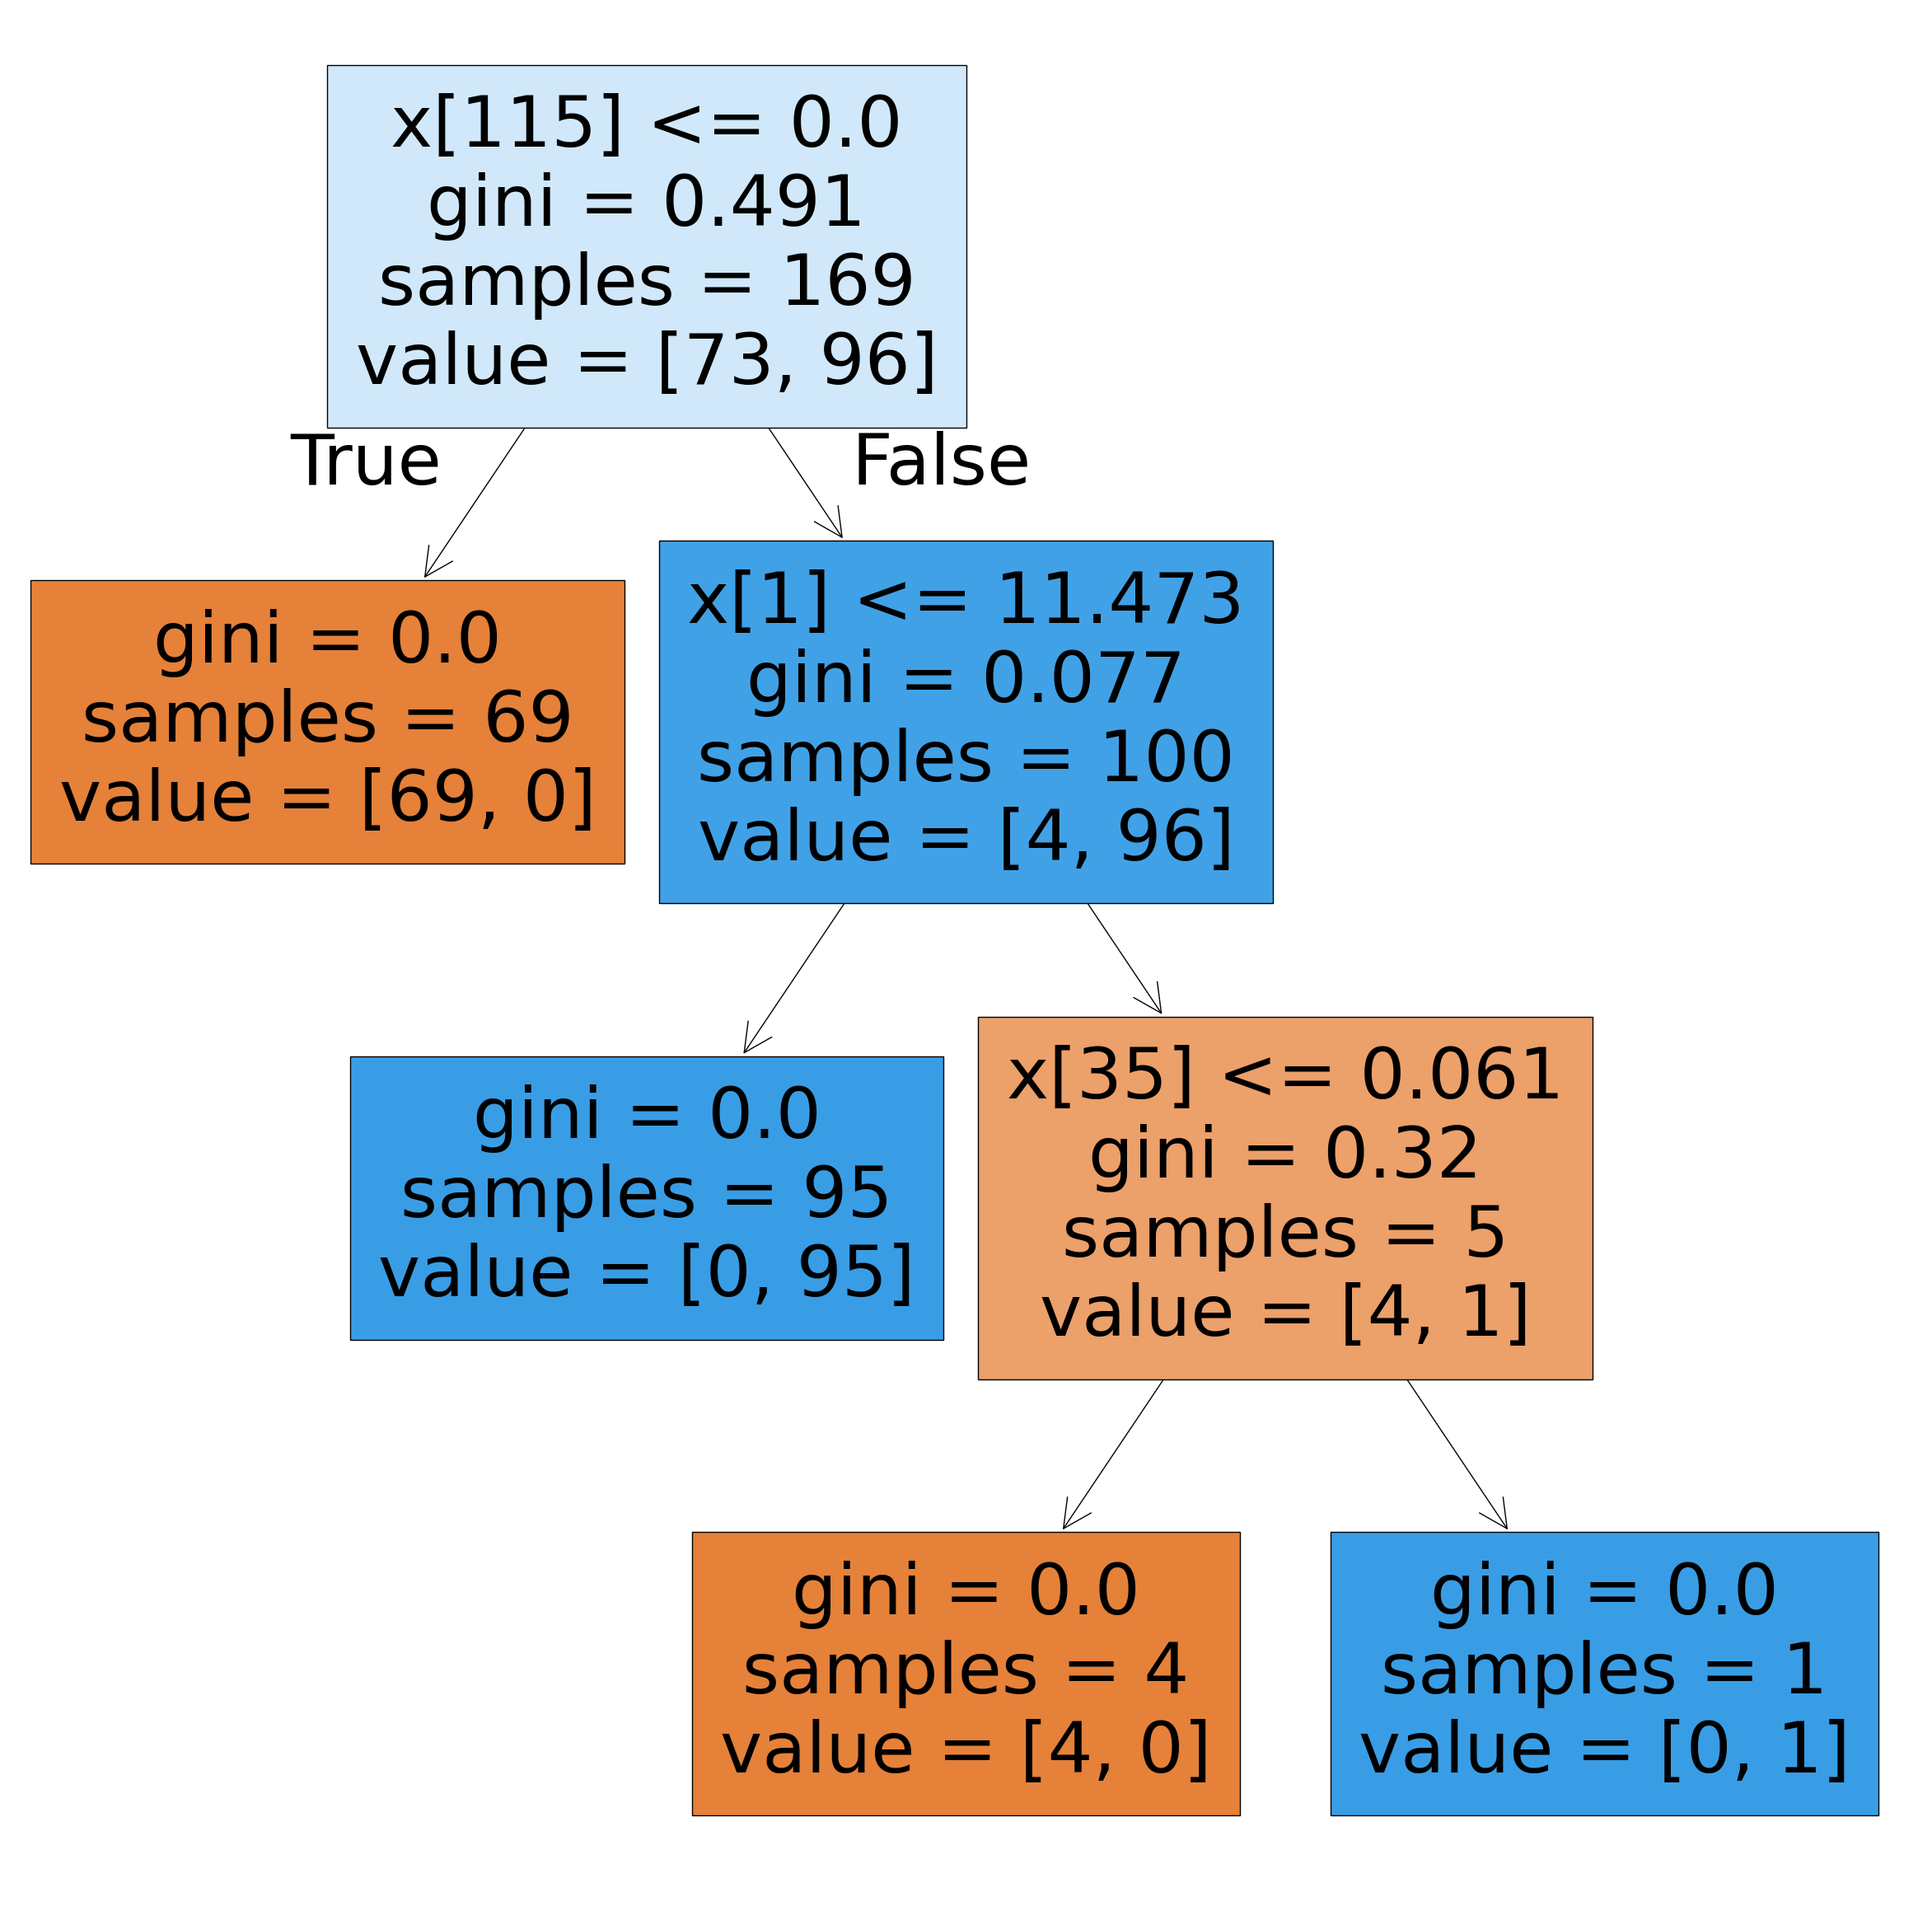

In [30]:
# Draw the decision tree plot with max_depth=5
audio_five_tree = audio_trees[4] # getting fifth tree from the model evaluation
fig, ax = plt.subplots(figsize=(30,30))
tree.plot_tree(audio_five_tree, ax=ax, filled=True) #put this for all trees
plt.show()
fig.savefig("audio_five_tree_plot.pdf", format="pdf")

#Section 2
##**Comparing Decision Tree Classifiers**

**Dropping a column in X and a column in y**

In [31]:
X_dropped = X.drop(1)
y= pd.Series(y)
y_drop = y.drop(1)
X_train, X_test, y_train, y_test = train_test_split(X_dropped, y_drop, test_size=0.20, random_state=42)

**Comparing audio_five_tree to sound_tree2**

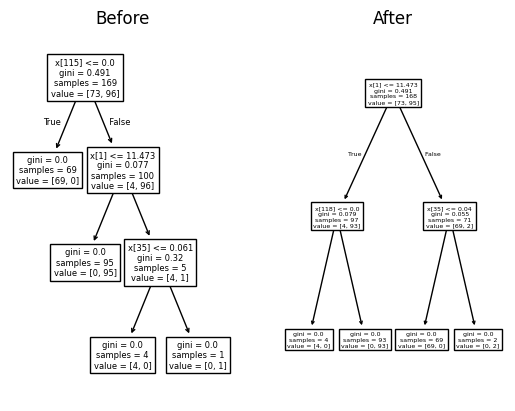

In [32]:
sound_tree2 = tree.DecisionTreeClassifier(max_depth=5, random_state=42)
sound_tree2 = sound_tree2.fit(X_train, y_train)
plt.subplot(1, 2, 1)
treeplot = tree.plot_tree(audio_five_tree)
plt.title("Before")
plt.subplot(1, 2, 2)
treeplot2 = tree.plot_tree(sound_tree2)
plt.title("After")
plt.show()
fig.savefig("audio_tree_plot_compare.pdf", format="pdf")

##Section 2.a
###Comparing models using a created bad classifier

In [33]:
# Create data with 50% for training. You need to use one hot encodr
X = audio_data.drop('label_text',axis=1)
y = audio_data['label_text']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

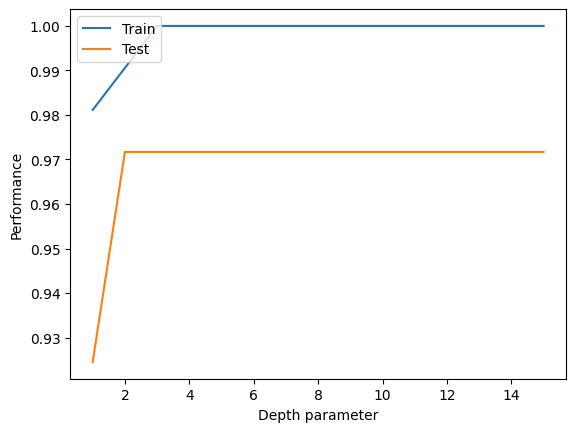

In [34]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16)
# Plot the above graph again
audio_train_acc = list()
audio_test_acc = list()
audio_trees = list()

for x in range(1,16):
  audio_tree = tree.DecisionTreeClassifier(random_state=42, max_depth=x)
  audio_tree.fit(X_train, y_train)
  audio_trees.append(audio_tree)
  audio_train_pred = audio_tree.predict(X_train)
  audio_test_pred = audio_tree.predict(X_test)
  audio_train_acc.append(accuracy_score(y_train, audio_train_pred))
  audio_test_acc.append(accuracy_score(y_test, audio_test_pred))
plt.plot(range(1,16),audio_train_acc, label='Train')
plt.plot(range(1,16),audio_test_acc, label='Test')
plt.legend(loc='upper left')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("audio_50_50_plot.pdf", format="pdf")

It appears that the testing performance rises slightly by around 1-2% when the data is split 50/50.

#**3. Cross Validation**
##**Bad Classifiers**

In [35]:
class BadClassifier():
  def __init__(self):
    pd = __import__('pandas')
    self.label_counts = pd.Series()
  def train(self, y_train):
    train_labels = pd.Series(y_train)
    label_counts = train_labels.value_counts(normalize=True)
    self.label_counts = label_counts.sort_index()
  def make_random_predictions(self, X_test):
    pred_labels=[]
    test_labels = pd.Series(y_test)
    test_label_counts = np.random.multinomial(X_test.shape[0],self.label_counts.values)
    for count,label in zip (test_label_counts,self.label_counts.index.values):
      pred_labels = pred_labels + [label for x in range(0,count)]
    np.random.shuffle(pred_labels)
    return pred_labels

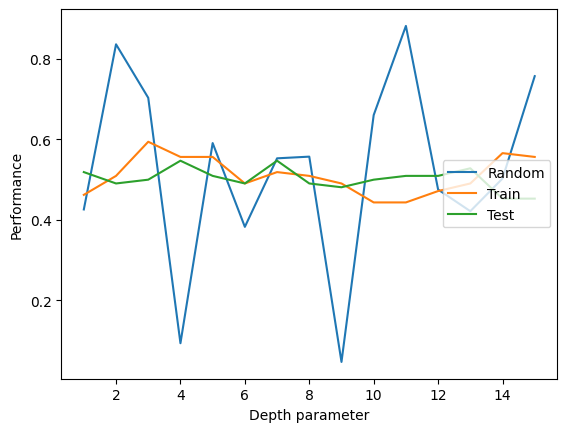

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

bad = BadClassifier()
accuracy = list()
train_errors = list()
test_errors = list()
for x in range(1,16):
  bad.train(y_train)
  y_pred_tr = bad.make_random_predictions(X_train)
  y_pred_te = bad.make_random_predictions(X_test)
  accuracy.append(np.random.rand())
  sound_trees =  tree.DecisionTreeClassifier(max_depth=x, random_state=42)
  sound_trees =  sound_trees.fit(X_train, y_train)
  train_errors.append(1 - accuracy_score(y_train, y_pred_tr))
  test_errors.append(1 - accuracy_score(y_test, y_pred_te))
# plotting
plt.plot(range(1,16),accuracy, label='Random')
plt.plot(range(1,16),train_errors, label='Train')
plt.plot(range(1,16),test_errors, label='Test')
plt.legend(loc='center right')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("audio_bad_50_50.pdf", format="pdf")

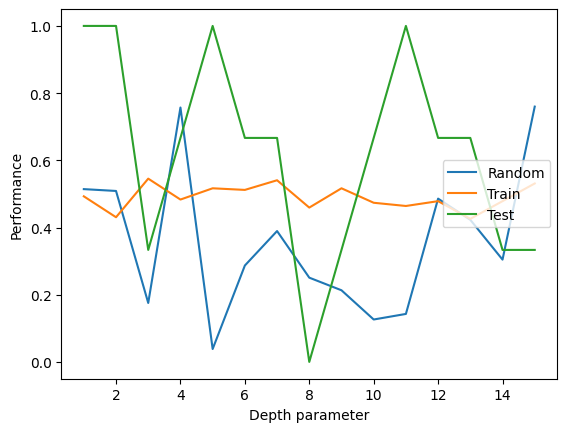

In [37]:

# Repeat above step but this time use only 1% of data for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

bad2 = BadClassifier()
accuracy2 = list()
train_errors2 = list()
test_errors2 = list()
for x in range(1,16):
  bad2.train(y_train)
  y_pred_tr = bad2.make_random_predictions(X_train)
  y_pred_te = bad2.make_random_predictions(X_test)
  accuracy2.append(np.random.rand())
  sound_trees =  tree.DecisionTreeClassifier(max_depth=x, random_state=42)
  sound_trees =  sound_trees.fit(X_train, y_train)
  train_errors2.append(1 - accuracy_score(y_train, y_pred_tr))
  test_errors2.append(1 - accuracy_score(y_test, y_pred_te))
# plotting
plt.plot(range(1,16),accuracy2, label='Random')
plt.plot(range(1,16),train_errors2, label='Train')
plt.plot(range(1,16),test_errors2, label='Test')
plt.legend(loc='center right')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')
plt.show()
fig.savefig("audio_bad_99_1.pdf", format="pdf")